2026-01-07 18:21:05.950342: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767810066.113541      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767810066.161344      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767810066.548743      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767810066.548780      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767810066.548782      23 computation_placer.cc:177] computation placer alr

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1767810102.708083      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1767810106.788842      79 service.cc:152] XLA service 0x7b9e90006870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767810106.788884      79 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1767810107.141140      79 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/1358 ━━━━━━━━━━━━━━━━━━━━ 2:18:45 6s/step - accuracy: 0.0000e+00 - loss: 3.5035

I0000 00:00:1767810111.089120      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 629s 459ms/step - accuracy: 0.3230 - loss: 2.5648 - val_accuracy: 0.6812 - val_loss: 1.0676
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 474s 349ms/step - accuracy: 0.7339 - loss: 0.8952 - val_accuracy: 0.8177 - val_loss: 0.5865
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 475s 350ms/step - accuracy: 0.8027 - loss: 0.6210 - val_accuracy: 0.8196 - val_loss: 0.5814
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 477s 351ms/step - accuracy: 0.8464 - loss: 0.4732 - val_accuracy: 0.8698 - val_loss: 0.4058
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 474s 349ms/step - accuracy: 0.8653 - loss: 0.4103 - val_accuracy: 0.8530 - val_loss: 0.4761
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 467s 344ms/step - accuracy: 0.8832 - loss: 0.3510 - val_accuracy: 0.8797 - val_loss: 0.3750
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 463s 341ms/step - accuracy: 0.8968 - loss: 0.3053 - val_accuracy: 0.7998 - val_loss: 0.7227
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 460s 339ms/step - accuracy: 0.8

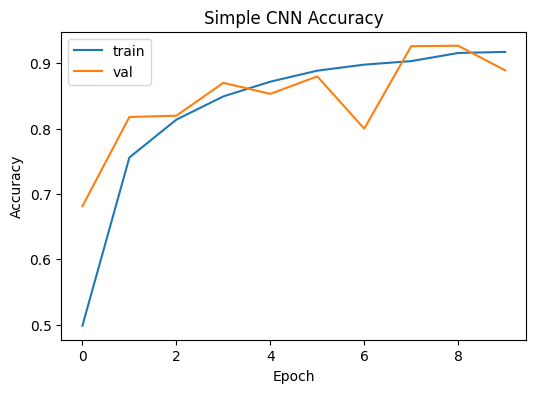

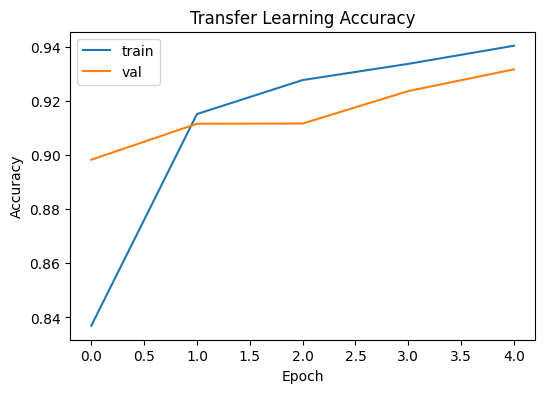

CNN Confusion Matrix:
 [[ 1  0  2 ...  7  0  4]
 [ 1  3  1 ...  9  1  5]
 [ 1  1  1 ...  1  2  0]
 ...
 [11 14  9 ... 96 10 31]
 [ 2  2  1 ...  7  0  0]
 [ 7  4  2 ... 41  0 11]]
Transfer Learning Confusion Matrix:
 [[  4   0   1 ...   9   2   3]
 [  1   2   1 ...  12   1   2]
 [  0   0   0 ...   4   0   3]
 ...
 [  7   8   6 ... 105   7  34]
 [  0   3   1 ...   4   0   2]
 [  4   4   1 ...  25   1   8]]


In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


DATA_DIR = "/kaggle/input/plantvillage-dataset/color"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS_CNN = 10
EPOCHS_TL = 5

# DATA GENERATORS (WITH AUGMENTATION)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED
)

NUM_CLASSES = train_gen.num_classes

# CLASS WEIGHTS
labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))

# SIMPLE CNN
cnn_model = keras.Sequential([
    layers.Conv2D(32, 3, activation="relu", input_shape=(*IMG_SIZE, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

cnn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_CNN,
    class_weight=class_weights
)

# CNN EVALUATION
val_preds = np.argmax(cnn_model.predict(val_gen), axis=1)
val_true = val_gen.classes
cm_cnn = confusion_matrix(val_true, val_preds)

# TRANSFER LEARNING
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

tl_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_tl = tl_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_TL,
    class_weight=class_weights
)

# TRANSFER LEARNING EVALUATION
val_preds_tl = np.argmax(tl_model.predict(val_gen), axis=1)
cm_tl = confusion_matrix(val_true, val_preds_tl)

# PLOTS
def plot_history(history, title):
    plt.figure(figsize=(6,4))
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history_cnn, "Simple CNN Accuracy")
plot_history(history_tl, "Transfer Learning Accuracy")

print("CNN Confusion Matrix:\n", cm_cnn)
print("Transfer Learning Confusion Matrix:\n", cm_tl)
